<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align='center'>
  <img src='https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png' alt='UNAM' width='200'/>
</p>

<hr style='height:3px; background-color:#0B6E4F; border:none;'/>

$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Algoritmo de Teoría — Gradient Boosting}$  

\begin{array}{rl}
\textbf{Docente:} & \text{Dra. Jessica Sarahi Méndez Rincón} \\[6pt]
\textbf{Ayudante de laboratorio:} & \text{Diego Eduardo Peña Villegas} \\[6pt]
\textbf{Alumna:} & \text{Peredo López Citlalli Abigail} \\[6pt]
\textbf{Fecha:} & \text{2026}
\end{array}

</center>

---
# 1. Descripción del Algoritmo

Gradient Boosting es un algoritmo de aprendizaje supervisado de tipo *ensemble* que construye un **modelo aditivo** de forma secuencial. Sus tres principios clave son:

**Aprendizaje del Error:** El primer modelo hace una predicción burda (el promedio de $y$). El segundo modelo no intenta predecir el resultado real, sino que intenta predecir el **residuo** (error) que cometió el primero.

**Corrección en Cascada:** Cada nuevo árbol que se añade se enfoca exclusivamente en corregir lo que los anteriores todavía no entienden bien.

**Optimización del Gradiente:** El nombre viene de que se usa el **descenso de gradiente** para minimizar una función de pérdida, moviendo las predicciones en la dirección que reduce el error más rápidamente.

---
# 2. Fundamentos Matemáticos

## 2.1 Modelo Aditivo

La predicción final es la **suma ponderada de modelos simples** (weak learners):

$$F_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)$$

donde $h_m(x)$ son los árboles de decisión y $\gamma_m$ es el peso (learning rate) de cada uno.

## 2.2 Función de Pérdida

Se busca minimizar una función de pérdida $L$. Para regresión se usa el **Error Cuadrático Medio (MSE)**:

$$L(y, \hat{y}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

## 2.3 Predicción Inicial

El modelo se inicializa con la constante que minimiza la pérdida total:

$$F_0(x) = \underset{\gamma}{\arg\min} \sum_i L(y_i, \gamma) = \bar{y}$$

Para MSE, esto es simplemente el **promedio de $y$**.

## 2.4 Pseudo-Residuos (Gradiente Negativo)

En cada iteración $m$, se calculan los **pseudo-residuos** como el gradiente negativo de la pérdida respecto a la predicción actual:

$$r_{im} = -\frac{\partial L(y_i,\, F(x_i))}{\partial F(x_i)} \Bigg|_{F(x) = F_{m-1}(x)}$$

Para MSE, esto se simplifica a:

$$r_{im} = y_i - F_{m-1}(x_i)$$

Es decir, el residuo es la diferencia entre el valor real y la predicción acumulada hasta el momento.

## 2.5 Actualización del Modelo

Se entrena un árbol $h_m(x)$ sobre los residuos $r_{im}$, y se actualiza el modelo sumando una fracción del nuevo árbol:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

donde $\eta$ es la **tasa de aprendizaje** (*learning rate*) que controla cuánto contribuye cada árbol.

## 2.6 Criterio de División del Árbol: Varianza Ponderada (MSE)

Para cada posible corte, el árbol regresor calcula la **varianza ponderada** de las dos ramas resultantes:

$$MSE_{\text{ponderado}} = \frac{n_{izq} \cdot \text{Var}(y_{izq}) + n_{der} \cdot \text{Var}(y_{der})}{n_{\text{total}}}$$

Se elige el corte que **minimice** este valor. Ya no se usa entropía (que es para clasificación), sino MSE porque estamos haciendo **regresión sobre los residuos**.

## 2.7 Valor de una Hoja

El valor que predice cada hoja es el **promedio de los residuos** que cayeron en ella:

$$\text{valor\_hoja} = \frac{1}{|R_j|} \sum_{i \in R_j} r_i$$

## 2.8 Métricas de Complejidad

| Métrica | Complejidad | Notas |
|---|---|---|
| **Entrenamiento** | $O(M \cdot n \cdot d \cdot \log n)$ | $M$ = árboles, $n$ = muestras, $d$ = features. **No paralelizable** fácilmente porque cada árbol depende del anterior |
| **Predicción** | $O(M \cdot \text{profundidad})$ | Muy eficiente; sólo recorre la cadena de árboles |
| **Espacio** | $O(M \cdot \text{nodos})$ | Se debe almacenar la secuencia completa de árboles para reconstruir la predicción final |

---
# 3. Pseudocódigo

```
Algoritmo: Gradient Boosting (Regresión)
==========================================================
ENTRADA:
    D              → dataset (X, y)
    L              → función de pérdida (MSE)
    M              → número de iteraciones (árboles)
    η              → tasa de aprendizaje (learning rate)
    max_depth      → profundidad máxima de cada árbol

SALIDA:
    F_M(x)         → modelo final

----------------------------------------------------------
PASO 1 — Inicializar el modelo con una constante:

    F_0(x) = argmin_γ  Σ L(yᵢ, γ)   →   para MSE: F_0 = media(y)
    f_acumulado ← vector lleno con F_0

PASO 2 — Para m = 1 hasta M:

    2a. Calcular los pseudo-residuos para cada ejemplo:
            rᵢₘ = -∂L(yᵢ, F(xᵢ)) / ∂F(xᵢ)
            Para MSE:  rᵢₘ = yᵢ - f_acumulado[i]

    2b. Entrenar un árbol regresor h_m(x) usando los residuos
        rᵢₘ como el nuevo "objetivo" (target):
            árbol_m.fit(X, residuos)

    2c. Actualizar el modelo sumando una fracción del nuevo árbol:
            F_m(x) = F_{m-1}(x) + η · h_m(x)
            f_acumulado += η * árbol_m.predict(X)

    2d. Guardar árbol_m en lista_arboles

PASO 3 — Predicción para X_nuevo:
    y_pred ← vector lleno con F_0
    PARA cada árbol en lista_arboles:
        y_pred += η * árbol.predict(X_nuevo)
    RETORNAR y_pred

==========================================================
SUB-ALGORITMO: Árbol Regresor — Criterio de División
----------------------------------------------------------
PARA cada feature f en X:
    PARA cada umbral t en valores_únicos(X[:, f]):
        y_izq ← y donde X[:, f] <= t
        y_der ← y donde X[:, f]  > t
        SI y_izq o y_der están vacíos: continuar
        mse_pond ← (len(y_izq)*Var(y_izq) + len(y_der)*Var(y_der)) / n
        SI mse_pond < mejor_mse:
            mejor_mse    ← mse_pond
            mejor_feat   ← f
            mejor_umbral ← t
RETORNAR mejor_feat, mejor_umbral

Valor de hoja = media(residuos que cayeron en esa hoja)
```

---
# 4. Código

In [1]:
# ============================================================
# IMPORTACIONES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# ============================================================
# CLASE: Nodo
# Unidad básica del árbol de decisión.
# ============================================================
class Nodo:
    """
    Representa un nodo dentro de un árbol de decisión.

    Parámetros
    ----------
    feature   : int   → índice del feature sobre el que se divide
    threshold : float → valor umbral de la división
    left      : Nodo  → subárbol izquierdo  (X[:, feature] <= threshold)
    right     : Nodo  → subárbol derecho    (X[:, feature]  > threshold)
    value     : float → predicción si es hoja (promedio de residuos)
    """
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

    def es_hoja(self):
        """Retorna True si el nodo es una hoja (sin hijos)."""
        return self.value is not None

In [3]:
# ============================================================
# CLASE: ArbolDecisionRegresor
# Árbol de decisión para regresión sobre valores continuos.
# Criterio de impureza: Varianza Ponderada (equivalente a MSE).
# Nota: Se usa MSE y no Entropía porque estamos regresionando
# sobre los residuos, no clasificando.
# ============================================================
class ArbolDecisionRegresor:
    """
    Árbol de decisión regresor usado como estimador base
    dentro de Gradient Boosting.

    Parámetros
    ----------
    max_depth : int → profundidad máxima del árbol (default: 3)
    """

    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.root      = None

    # ----------------------------------------------------------
    # ENTRENAMIENTO
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Construye el árbol recursivamente.

        Parámetros
        ----------
        X : np.ndarray (n_muestras, n_features)
        y : np.ndarray (n_muestras,) → residuos a predecir
        """
        self.root = self._crear_arbol(X, y, depth=0)

    def _crear_arbol(self, X, y, depth):
        """
        Crea nodos recursivamente.
        Condición de parada: profundidad máxima o menos de 2 muestras.
        """
        n_muestras = len(y)

        # Condición de parada → hoja con el promedio de residuos
        if depth >= self.max_depth or n_muestras < 2:
            return Nodo(value=np.mean(y))

        mejor_feat, mejor_umbral = self._mejor_criterio(X, y)

        # Si no hay corte útil → hoja
        if mejor_feat is None:
            return Nodo(value=np.mean(y))

        # Particionar datos según el mejor corte
        mascara_izq = X[:, mejor_feat] <= mejor_umbral
        mascara_der = ~mascara_izq

        # Recursión para hijos
        hijo_izq = self._crear_arbol(X[mascara_izq], y[mascara_izq], depth + 1)
        hijo_der = self._crear_arbol(X[mascara_der], y[mascara_der], depth + 1)

        return Nodo(feature=mejor_feat, threshold=mejor_umbral,
                    left=hijo_izq, right=hijo_der)

    def _mejor_criterio(self, X, y):
        """
        Encuentra el feature y umbral que minimizan la varianza
        ponderada (MSE) entre las dos ramas resultantes.

        Retorna
        -------
        mejor_feat   : int   → índice del mejor feature
        mejor_umbral : float → valor del mejor umbral
        """
        mejor_mse    = np.var(y)  # MSE sin dividir (línea base)
        mejor_feat   = None
        mejor_umbral = None

        for idx_feat in range(X.shape[1]):
            for umbral in np.unique(X[:, idx_feat]):
                y_izq = y[X[:, idx_feat] <= umbral]
                y_der = y[X[:, idx_feat] >  umbral]

                # Saltar particiones vacías
                if len(y_izq) == 0 or len(y_der) == 0:
                    continue

                # MSE ponderado por tamaño de cada rama
                mse_ponderado = (
                    len(y_izq) * np.var(y_izq) +
                    len(y_der) * np.var(y_der)
                ) / len(y)

                if mse_ponderado < mejor_mse:
                    mejor_mse    = mse_ponderado
                    mejor_feat   = idx_feat
                    mejor_umbral = umbral

        return mejor_feat, mejor_umbral

    # ----------------------------------------------------------
    # PREDICCIÓN
    # ----------------------------------------------------------
    def predict(self, X):
        """
        Predice un valor continuo para cada muestra en X.

        Parámetros
        ----------
        X : np.ndarray (n_muestras, n_features)

        Retorna
        -------
        np.ndarray con las predicciones
        """
        return np.array([self._recorrer_arbol(x, self.root) for x in X])

    def _recorrer_arbol(self, x, nodo):
        """Recorre el árbol para una sola muestra x."""
        if nodo.es_hoja():
            return nodo.value
        if x[nodo.feature] <= nodo.threshold:
            return self._recorrer_arbol(x, nodo.left)
        return self._recorrer_arbol(x, nodo.right)

In [4]:
# ============================================================
# CLASE: GradientBoostingDesdeCero
# Ensemble secuencial: cada árbol corrige los residuos
# del modelo acumulado hasta ese momento.
# ============================================================
class GradientBoostingDesdeCero:
    """
    Gradient Boosting para regresión implementado desde cero.

    Parámetros
    ----------
    n_estimators  : int   → número de árboles (default: 10)
    learning_rate : float → escala la contribución de cada árbol η (default: 0.1)
    max_depth     : int   → profundidad máxima de cada árbol base (default: 3)

    Atributos (tras fit)
    --------------------
    init_prediction : float       → predicción base = media(y) = F_0
    trees           : list[Nodo]  → lista de árboles entrenados secuencialmente
    """

    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3):
        self.n_estimators   = n_estimators
        self.learning_rate  = learning_rate
        self.max_depth      = max_depth
        self.trees          = []
        self.init_prediction = None

    # ----------------------------------------------------------
    # ENTRENAMIENTO
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Entrena el modelo Gradient Boosting.

        Parámetros
        ----------
        X : np.ndarray (n_muestras, n_features)
        y : np.ndarray (n_muestras,) → valores objetivo reales
        """
        # Asegurar tipo float para operaciones aritméticas
        y = y.astype(float)

        # PASO 1: F_0 = media(y)  →  predicción inicial
        self.init_prediction = np.mean(y)
        f_acumulado = np.full(y.shape, self.init_prediction)

        # PASO 2: Boosting iterativo
        for _ in range(self.n_estimators):

            # 2a. Pseudo-residuos: r = y - F_{m-1}(x)
            residuos = y - f_acumulado

            # 2b. Entrenar árbol regresor sobre los residuos
            arbol = ArbolDecisionRegresor(max_depth=self.max_depth)
            arbol.fit(X, residuos)

            # 2c. Actualizar modelo: F_m = F_{m-1} + η · h_m(x)
            f_acumulado += self.learning_rate * arbol.predict(X)

            # 2d. Guardar árbol en la secuencia
            self.trees.append(arbol)

    # ----------------------------------------------------------
    # PREDICCIÓN
    # ----------------------------------------------------------
    def predict(self, X):
        """
        Genera predicciones para nuevas muestras.

        Parámetros
        ----------
        X : np.ndarray (n_muestras, n_features)

        Retorna
        -------
        np.ndarray con las predicciones finales F_M(x)
        """
        # Partir de la predicción base F_0
        y_pred = np.full(X.shape[0], self.init_prediction)

        # Acumular contribución de cada árbol
        for arbol in self.trees:
            y_pred += self.learning_rate * arbol.predict(X)

        return y_pred

---
# 5. Verificación del Código (Ejemplo de Clase)

Se reproduce el ejemplo del notebook de clase para confirmar que la implementación es correcta.  
**Resultado esperado:** Predicción para $x=6 \approx 9.98$

In [5]:
# ============================================================
# VERIFICACIÓN — Ejemplo del notebook de clase
# Datos: y = 2x  (relación lineal perfecta)
# ============================================================

X_clase = np.array([[1], [2], [3], [4], [5]])
y_clase = np.array([2, 4, 6, 8, 10])

gb_clase = GradientBoostingDesdeCero(n_estimators=50, learning_rate=0.1)
gb_clase.fit(X_clase, y_clase)

pred_clase = gb_clase.predict(np.array([[6]]))
print(f"Predicción para x=6: {pred_clase[0]:.2f}")
print(f"Valor esperado:       9.98  (del notebook de clase)")

Predicción para x=6: 9.98
Valor esperado:       9.98  (del notebook de clase)


---
# 6. Aplicación con Nuevo Input

> **Instrucción para el examen:** Sustituir los datos de la celda. El resto del código (modelo, entrenamiento, predicción y métricas) se ejecuta sin modificaciones.

In [ ]:

# --- DATOS DE ENTRENAMIENTO ---
# Sustituir con los datos que dé la maestra
# X_train debe ser un arreglo 2D: shape (n_muestras, n_features)
# y_train debe ser un arreglo 1D: shape (n_muestras,)

X_train = np.array([  # <-- reemplazar
    [1],
    [2],
    [3],
    [4],
    [5]
])

y_train = np.array([2, 4, 6, 8, 10])  # <-- reemplazar

# --- DATOS DE PRUEBA ---
# Valor(es) para los que se quiere obtener predicción
X_test = np.array([[6]])  # <-- reemplazar

# --- HIPERPARÁMETROS ---
N_ESTIMATORS  = 50
LEARNING_RATE = 0.1
MAX_DEPTH     = 3

In [7]:
# ============================================================
# ENTRENAMIENTO Y PREDICCIÓN
# ============================================================

# Instanciar y entrenar modelo
modelo = GradientBoostingDesdeCero(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH
)
modelo.fit(X_train, y_train)

# Predicciones sobre entrenamiento
y_pred_train = modelo.predict(X_train)

# Predicción sobre el nuevo input
y_pred_test = modelo.predict(X_test)

print("=" * 50)
print(" PREDICCIONES EN ENTRENAMIENTO")
print("=" * 50)
for i in range(len(y_train)):
    print(f"  Real: {float(y_train[i]):8.2f}  |  Predicho: {y_pred_train[i]:8.2f}  |  Error: {abs(float(y_train[i]) - y_pred_train[i]):8.2f}")

print("\n" + "=" * 50)
print(" PREDICCIÓN PARA NUEVO INPUT")
print("=" * 50)
for i, pred in enumerate(y_pred_test):
    print(f"  X_test[{i}] = {X_test[i]}  →  Predicción: {pred:.4f}")

 PREDICCIONES EN ENTRENAMIENTO
  Real:     2.00  |  Predicho:     2.02  |  Error:     0.02
  Real:     4.00  |  Predicho:     4.01  |  Error:     0.01
  Real:     6.00  |  Predicho:     6.00  |  Error:     0.00
  Real:     8.00  |  Predicho:     7.99  |  Error:     0.01
  Real:    10.00  |  Predicho:     9.98  |  Error:     0.02

 PREDICCIÓN PARA NUEVO INPUT
  X_test[0] = [6]  →  Predicción: 9.9794


In [8]:
# ============================================================
# MÉTRICAS DE DESEMPEÑO
# ============================================================

y_train_float = y_train.astype(float)

# MSE — Error Cuadrático Medio
mse = np.mean((y_train_float - y_pred_train) ** 2)

# RMSE — Raíz del Error Cuadrático Medio (mismas unidades que y)
rmse = np.sqrt(mse)

# MAE — Error Absoluto Medio
mae = np.mean(np.abs(y_train_float - y_pred_train))

# R² — Coeficiente de determinación
ss_res = np.sum((y_train_float - y_pred_train) ** 2)
ss_tot = np.sum((y_train_float - np.mean(y_train_float)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print(" MÉTRICAS DE DESEMPEÑO (train)")
print("=" * 40)
print(f"  MSE  (Error Cuadrático Medio):    {mse:.4f}")
print(f"  RMSE (Raíz del MSE):              {rmse:.4f}")
print(f"  MAE  (Error Absoluto Medio):      {mae:.4f}")
print(f"  R²   (Coeficiente determinación): {r2:.4f}")
print("\nInterpretación:")
print(f"  → R² = {r2:.4f}: el modelo explica el {r2*100:.1f}% de la varianza en y.")
print(f"  → RMSE = {rmse:.4f}: error promedio en las mismas unidades que y.")

 MÉTRICAS DE DESEMPEÑO (train)
  MSE  (Error Cuadrático Medio):    0.0002
  RMSE (Raíz del MSE):              0.0146
  MAE  (Error Absoluto Medio):      0.0124
  R²   (Coeficiente determinación): 1.0000

Interpretación:
  → R² = 1.0000: el modelo explica el 100.0% de la varianza en y.
  → RMSE = 0.0146: error promedio en las mismas unidades que y.


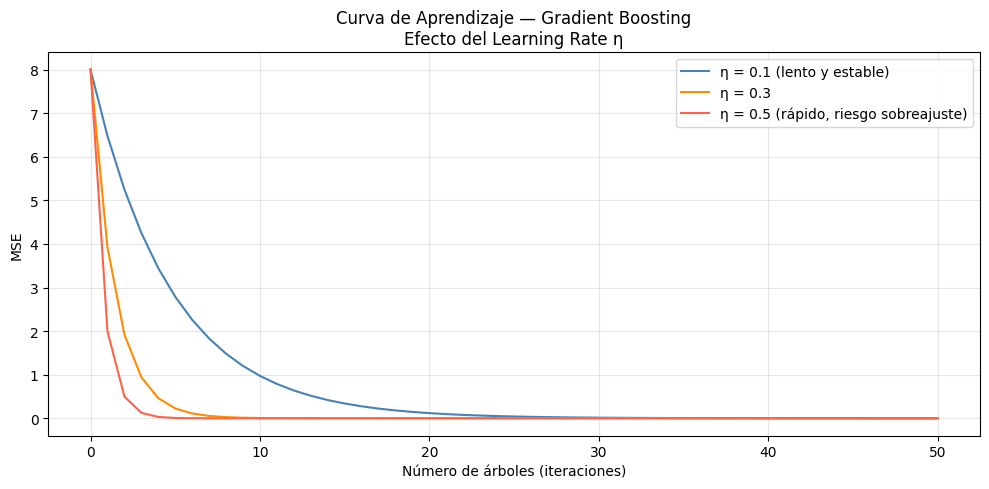

Interpretación de la curva:
  · η pequeño (0.1): converge lento pero de forma estable.
  · η grande (0.5): converge rápido pero puede sobreajustar.
  · Recomendación: η=0.1 con más árboles suele generalizar mejor.


In [9]:
# ============================================================
# VISUALIZACIÓN — Curva de aprendizaje por iteración
# Muestra cómo el MSE disminuye con cada árbol añadido
# ============================================================

def curva_aprendizaje_gb(X, y, n_estimators=50, learning_rate=0.1, max_depth=3):
    """
    Registra el MSE tras cada árbol para visualizar la
    convergencia del Gradient Boosting.
    """
    y = y.astype(float)
    f_acumulado = np.full(y.shape, np.mean(y))
    mse_historial = [np.mean((y - f_acumulado) ** 2)]

    for _ in range(n_estimators):
        residuos = y - f_acumulado
        arbol = ArbolDecisionRegresor(max_depth=max_depth)
        arbol.fit(X, residuos)
        f_acumulado += learning_rate * arbol.predict(X)
        mse_historial.append(np.mean((y - f_acumulado) ** 2))

    return mse_historial


# Comparar tres learning rates
mse_01 = curva_aprendizaje_gb(X_train, y_train, N_ESTIMATORS, learning_rate=0.1)
mse_03 = curva_aprendizaje_gb(X_train, y_train, N_ESTIMATORS, learning_rate=0.3)
mse_05 = curva_aprendizaje_gb(X_train, y_train, N_ESTIMATORS, learning_rate=0.5)

plt.figure(figsize=(10, 5))
plt.plot(mse_01, label='η = 0.1 (lento y estable)',    color='steelblue')
plt.plot(mse_03, label='η = 0.3',                      color='darkorange')
plt.plot(mse_05, label='η = 0.5 (rápido, riesgo sobreajuste)', color='tomato')
plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('MSE')
plt.title('Curva de Aprendizaje — Gradient Boosting\nEfecto del Learning Rate η')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretación de la curva:")
print("  · η pequeño (0.1): converge lento pero de forma estable.")
print("  · η grande (0.5): converge rápido pero puede sobreajustar.")
print("  · Recomendación: η=0.1 con más árboles suele generalizar mejor.")

<hr/>
<footer style='text-align:center; font-size:12px; color:gray;'>
© 2026 UNAM Facultad de Ciencias – Todos los derechos reservados
</footer>